# Student Performance Analysis

Exploratory Data Analysis of student performance using Python, Pandas, NumPy, Matplotlib and Seaborn.

## Objectives
- Understand the dataset structure and quality
- Explore distributions and relationships
- Identify factors associated with final scores
- Summarize practical findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/student_performance.csv')
df.head()

,gender,age,study_hours,attendance,parental_education,internet_access,sleep_hours,previous_score,final_score
0,male,17,6.2,69.8,high school,yes,7.7,88.5,80.2
1,male,17,2.5,80.2,high school,yes,7.9,77.1,70.0
2,female,18,4.1,71.1,high school,yes,5.6,60.4,58.9
3,female,17,1.6,63.9,bachelor,yes,8.2,78.8,64.8
4,male,20,1.6,71.7,master,yes,8.4,69.6,60.6


In [3]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Shape: (200, 9)

Data types:
gender                    str
age                     int64
study_hours           float64
attendance            float64
parental_education        str
internet_access           str
sleep_hours           float64
previous_score        float64
final_score           float64
dtype: object

Missing values:
gender                0
age                   0
study_hours           0
attendance            0
parental_education    0
internet_access       0
sleep_hours           0
previous_score        0
final_score           0
dtype: int64


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,200,2,male,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,200.0,NaN,NaN,NaN,19.39,1.652743,17.0,18.0,19.0,21.0,22.0
study_hours,200.0,NaN,NaN,NaN,4.529,1.868802,1.0,3.2,4.5,6.125,8.0
attendance,200.0,NaN,NaN,NaN,79.1935,11.328929,60.2,70.15,78.55,88.725,99.8
parental_education,200,3,bachelor,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_access,200,2,yes,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,200.0,NaN,NaN,NaN,7.0675,1.109979,5.1,6.1,7.1,8.1,9.0
previous_score,200.0,NaN,NaN,NaN,66.689,17.012289,36.0,51.8,68.45,80.625,94.8
final_score,200.0,NaN,NaN,NaN,66.499,9.673899,43.8,59.925,66.35,73.25,91.1


## Univariate Analysis

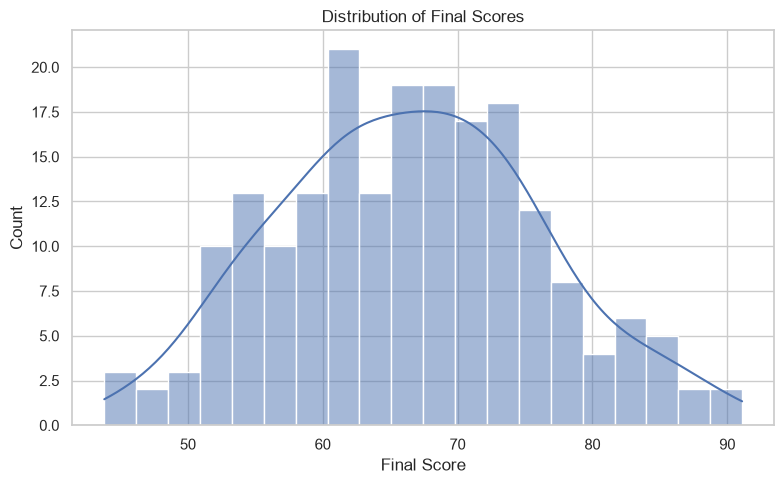

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['final_score'], bins=20, kde=True, ax=ax)
ax.set_title('Distribution of Final Scores')
ax.set_xlabel('Final Score')
plt.tight_layout()
plt.show()

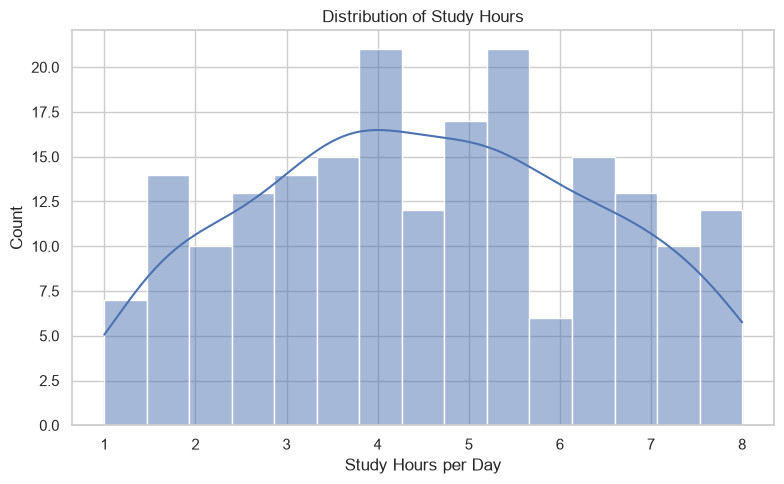

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['study_hours'], bins=15, kde=True, ax=ax)
ax.set_title('Distribution of Study Hours')
ax.set_xlabel('Study Hours per Day')
plt.tight_layout()
plt.show()

## Relationship Analysis

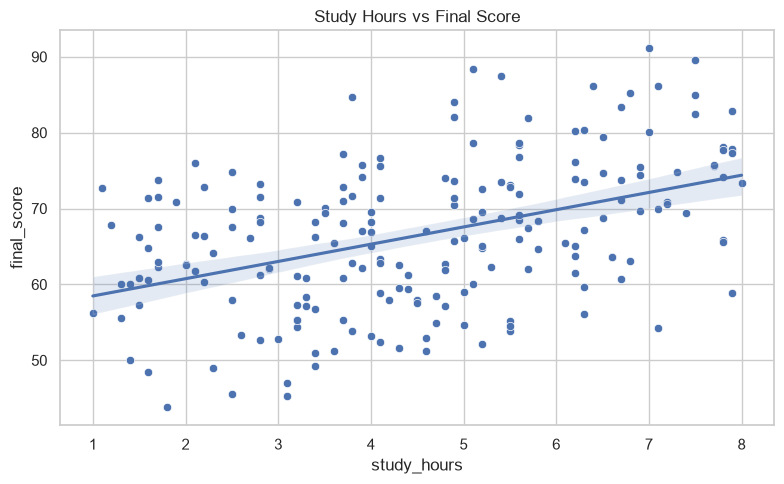

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours', y='final_score', ax=ax)
sns.regplot(data=df, x='study_hours', y='final_score', scatter=False, ax=ax)
ax.set_title('Study Hours vs Final Score')
plt.tight_layout()
plt.show()

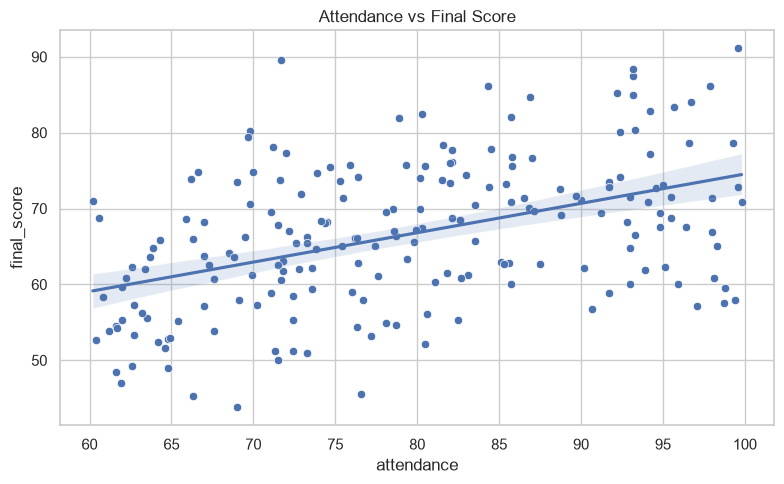

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='attendance', y='final_score', ax=ax)
sns.regplot(data=df, x='attendance', y='final_score', scatter=False, ax=ax)
ax.set_title('Attendance vs Final Score')
plt.tight_layout()
plt.show()

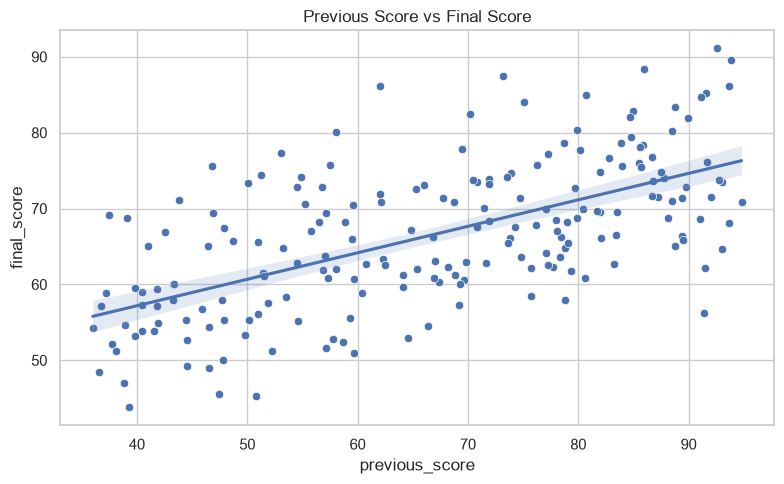

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='previous_score', y='final_score', ax=ax)
sns.regplot(data=df, x='previous_score', y='final_score', scatter=False, ax=ax)
ax.set_title('Previous Score vs Final Score')
plt.tight_layout()
plt.show()

## Group Analysis

In [10]:
print('Average final score by gender:')
display(df.groupby('gender')['final_score'].mean().round(2).sort_values(ascending=False))

print('Average final score by parental education:')
display(df.groupby('parental_education')['final_score'].mean().round(2).sort_values(ascending=False))

print('Average final score by internet access:')
display(df.groupby('internet_access')['final_score'].mean().round(2).sort_values(ascending=False))

Average final score by gender:


gender
male      66.91
female    66.07
Name: final_score, dtype: float64

Average final score by parental education:


parental_education
high school    67.11
master         66.67
bachelor       65.88
Name: final_score, dtype: float64

Average final score by internet access:


internet_access
yes    66.73
no     64.80
Name: final_score, dtype: float64

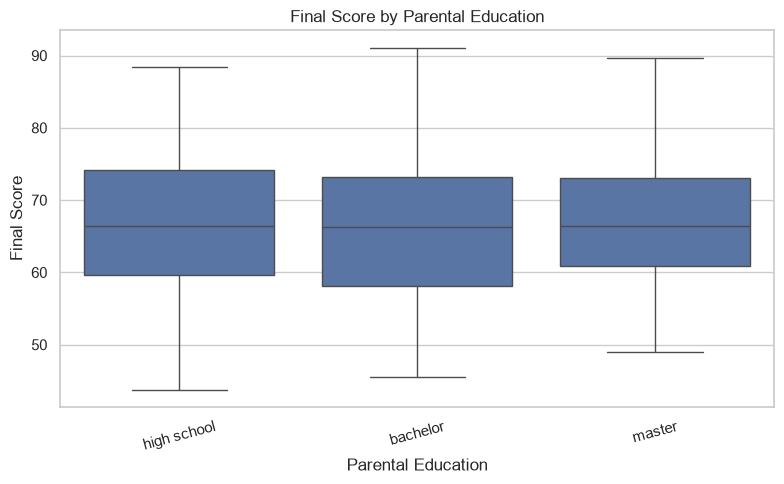

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='parental_education', y='final_score', ax=ax)
ax.set_title('Final Score by Parental Education')
ax.set_xlabel('Parental Education')
ax.set_ylabel('Final Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Correlation Analysis

,age,study_hours,attendance,sleep_hours,previous_score,final_score
age,1.00,-0.07,0.00,-0.10,-0.19,-0.17
study_hours,-0.07,1.00,0.07,-0.01,0.02,0.44
attendance,0.00,0.07,1.00,-0.00,0.07,0.45
sleep_hours,-0.10,-0.01,-0.00,1.00,-0.04,0.12
previous_score,-0.19,0.02,0.07,-0.04,1.00,0.61
final_score,-0.17,0.44,0.45,0.12,0.61,1.00


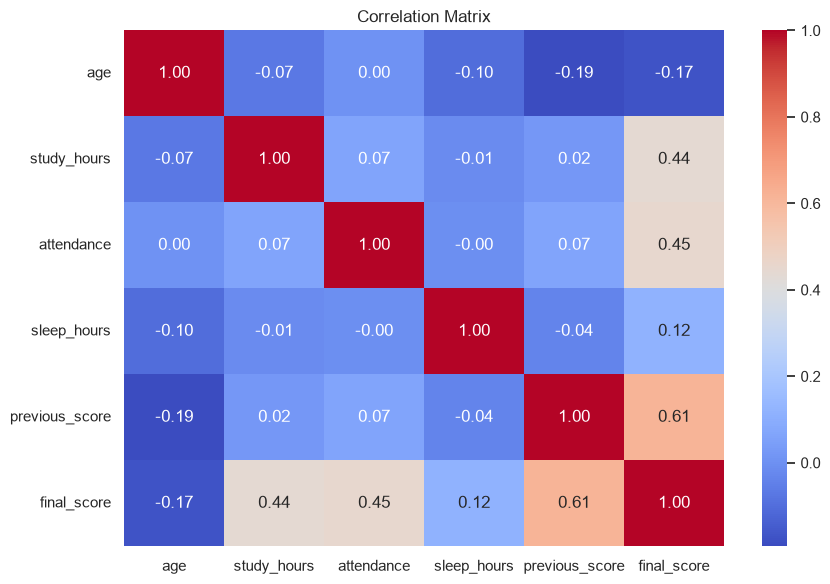

In [12]:
numeric_cols = ['age', 'study_hours', 'attendance', 'sleep_hours', 'previous_score', 'final_score']
corr = df[numeric_cols].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Findings

In [13]:
corr_with_final = corr['final_score'].drop('final_score').sort_values(key=np.abs, ascending=False)
print('Variables most associated with final score:')
display(corr_with_final.round(3))

print('Mean final score:', round(df['final_score'].mean(), 2))
print('Median final score:', round(df['final_score'].median(), 2))
print('Highest final score:', round(df['final_score'].max(), 2))

Variables most associated with final score:


previous_score    0.614
attendance        0.453
study_hours       0.439
age              -0.174
sleep_hours       0.116
Name: final_score, dtype: float64

Mean final score: 66.5
Median final score: 66.35
Highest final score: 91.1


### Conclusion
The analysis provides a practical overview of student performance and highlights relationships between final scores and measurable study-related factors. Correlation should be interpreted as association, not causation.